In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [2]:
df=pd.read_csv('dataset.csv')
df.head()

,text_type,text
0,spam,naturally irresistible your corporate identity...
1,spam,the stock trading gunslinger fanny is merrill ...
2,spam,unbelievable new homes made easy im wanting to...
3,spam,4 color printing special request additional in...
4,spam,do not have money get software cds from here s...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3613 entries, 0 to 3612
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text_type  3613 non-null   object
 1   text       3613 non-null   object
dtypes: object(2)
memory usage: 56.6+ KB


In [4]:
##Handle Missing & Duplicated Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_report = pd.DataFrame({
'Missing Count' : missing,
'Missing %'     : missing_pct
}).query('`Missing Count` > 0')

print("Missing Values:")
print(quality_report.to_string())
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing Values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
Duplicate rows: 0


In [6]:
# remove Duplicate rows
df.drop_duplicates(inplace=True)
print(f"Duplicate rows after removal: {df.duplicated().sum()}")

Duplicate rows after removal: 0


In [7]:
##Text Cleaning

In [8]:
Words_dict = {
    'u': 'you',
    'ur': 'your',
    'r': 'are',
    '4u': 'for you',
    'gr8': 'great',
    'b4': 'before',
    'plz': 'please',
    'msg': 'message',
    'txt': 'text',
}

def replace_words(text):
    text = text.lower()
    words = text.split()
    new_words = [Words_dict.get(word, word) for word in words]
    return " ".join(new_words)

df['text'] = df['text'].apply(replace_words)

In [9]:
def clean_text(text):
    text = str(text).lower()

    text = re.sub(r'(http|https):\/\/[\w\-]+(\.[\w\-]+)+([\w\-\.,@?^=%&:/~\+#]*[\w\-\@?^=%&/~\+#])?', ' <url> ', text)

    text = re.sub(r'£|\$|€', ' <cur> ', text)
    text = re.sub(r'\b\d+\b', ' <num> ', text)

    text = re.sub(r'[^a-z\s<>]', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['text'] = df['text'].apply(clean_text)
df.head()

,text_type,text
0,spam,naturally irresistible your corporate identity...
1,spam,the stock trading gunslinger fanny is merrill ...
2,spam,unbelievable new homes made easy im wanting to...
3,spam,<num> color printing special request additiona...
4,spam,do not have money get software cds from here s...


<Axes: xlabel='text_type'>

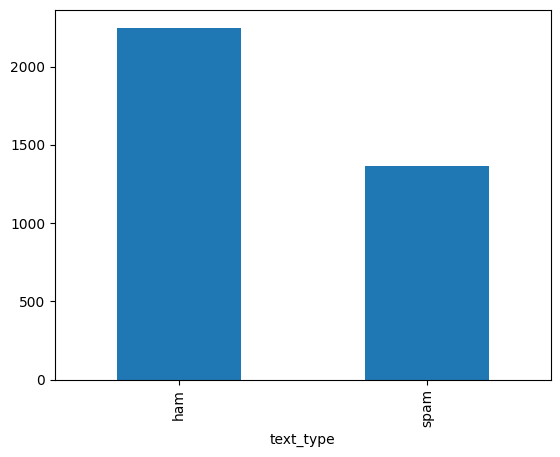

In [10]:
df['text_type'].value_counts().plot(kind='bar')

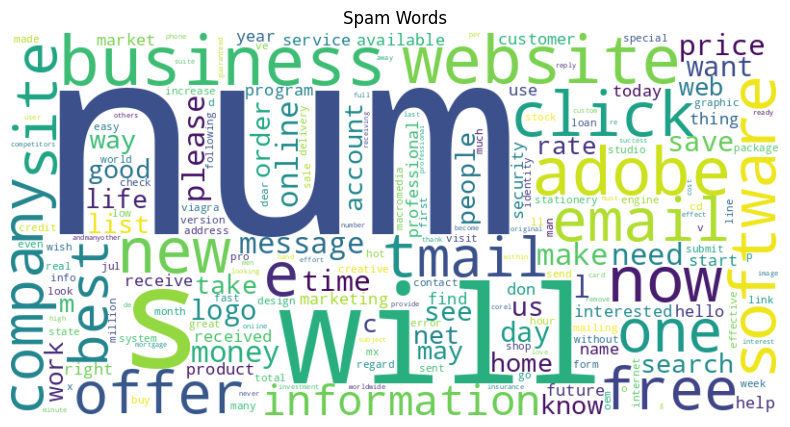

In [11]:
spam_text = " ".join(df[df['text_type'] == 'spam']['text'])

wordcloud_spam = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(spam_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.title("Spam Words")
plt.axis("off")
plt.show()

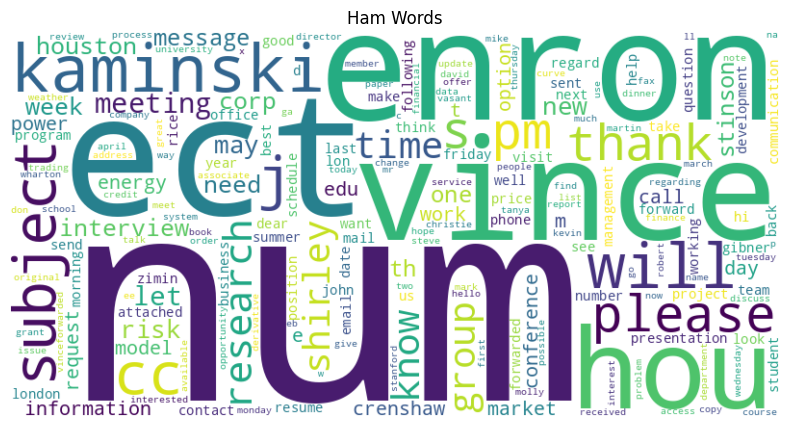

In [12]:
ham_text = " ".join(df[df['text_type'] == 'ham']['text'])

wordcloud_ham = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(ham_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.title("Ham Words")
plt.axis("off")
plt.show()

In [13]:
##Preprocessing

In [14]:
# Import required libraries

import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt

from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag

In [15]:
# Download NLTK resources

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [16]:
# Ensure text column is clean and valid

df['text'] = df['text'].astype(str)
df['text'] = df['text'].str.strip()
df = df[df['text'].str.len() > 0]
df.reset_index(drop=True, inplace=True)

In [17]:
# Split text into tokens

df['tokens'] = df['text'].apply(word_tokenize)

In [18]:
# Remove common stopwords

stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [19]:
# Apply stemming

stemmer = PorterStemmer()

df['stemmed_tokens'] = df['tokens'].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

In [20]:
# Convert POS tags to WordNet format

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [21]:
# Apply lemmatization

lemmatizer = WordNetLemmatizer()

df['lemmatized_tokens'] = df['tokens'].apply(
    lambda words: [
        lemmatizer.lemmatize(word, get_wordnet_pos(pos))
        for word, pos in pos_tag(words)
    ]
)

In [22]:
# Compare stemming vs lemmatization side by side

comparison_df = pd.DataFrame({
    "original": df['tokens'].explode(),
    "stemmed": df['stemmed_tokens'].explode(),
    "lemmatized": df['lemmatized_tokens'].explode()
})

comparison_df.head(200)

,original,stemmed,lemmatized
0,naturally,natur,naturally
0,irresistible,irresist,irresistible
0,corporate,corpor,corporate
0,identity,ident,identity
0,lt,lt,lt
...,...,...,...
3,color,color,color
3,printing,print,print
3,special,special,special
3,request,request,request


In [23]:
# Calculate unique vocabulary size

original_vocab = len(set(df['tokens'].explode()))
stemmed_vocab = len(set(df['stemmed_tokens'].explode()))
lemmatized_vocab = len(set(df['lemmatized_tokens'].explode()))

print("Original Vocabulary Size:", original_vocab)
print("Stemmed Vocabulary Size:", stemmed_vocab)
print("Lemmatized Vocabulary Size:", lemmatized_vocab)

Original Vocabulary Size: 20018
Stemmed Vocabulary Size: 15529
Lemmatized Vocabulary Size: 17614


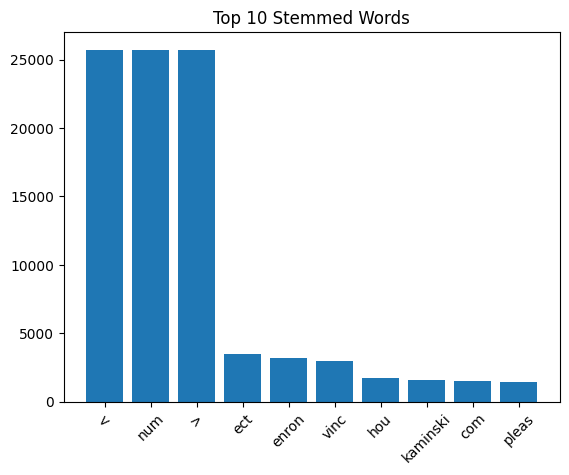

In [24]:
# Plot top 10 frequent stemmed words

from collections import Counter
import matplotlib.pyplot as plt

stem_words = df['stemmed_tokens'].explode()
stem_counts = Counter(stem_words)
top_stem = stem_counts.most_common(10)

words, counts = zip(*top_stem)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Stemmed Words")
plt.show()

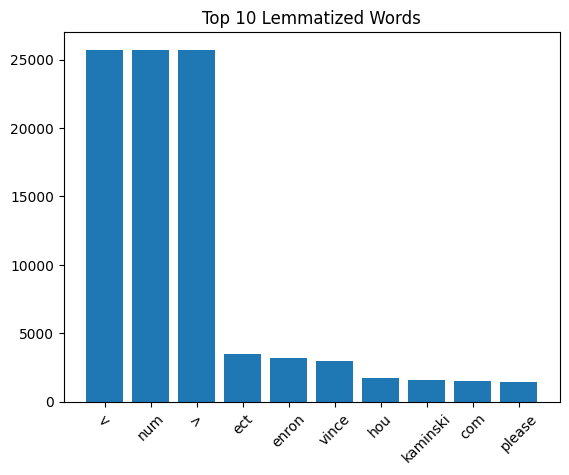

In [25]:
# Plot top 10 frequent lemmatized words

lemma_words = df['lemmatized_tokens'].explode()
lemma_counts = Counter(lemma_words)
top_lemma = lemma_counts.most_common(10)

words, counts = zip(*top_lemma)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Lemmatized Words")
plt.show()

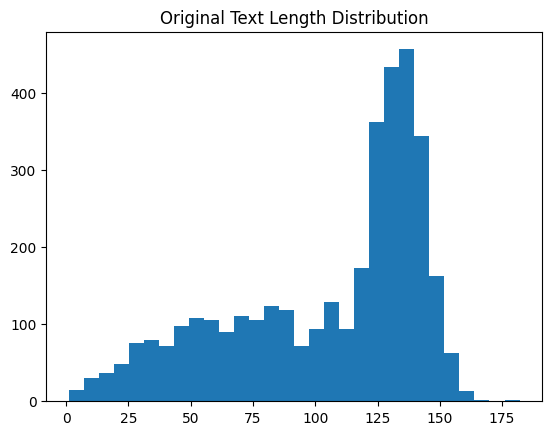

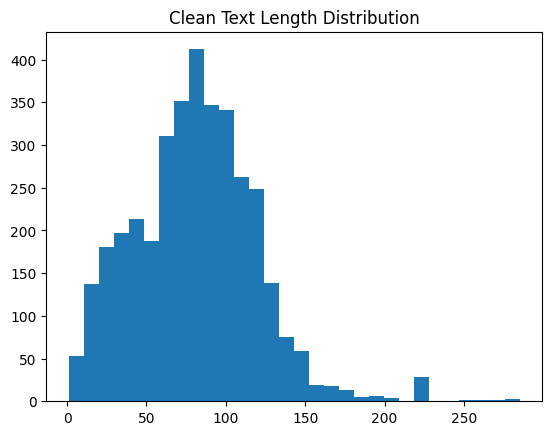

In [26]:
# Join lemmatized tokens into final clean text
df['clean_text'] = df['lemmatized_tokens'].apply(
    lambda words: " ".join(words)
)

# Compare message length before and after preprocessing

df['original_length'] = df['text'].str.split().apply(len)
df['clean_length'] = df['clean_text'].str.split().apply(len)

import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['original_length'], bins=30)
plt.title("Original Text Length Distribution")
plt.show()

plt.figure()
plt.hist(df['clean_length'], bins=30)
plt.title("Clean Text Length Distribution")
plt.show()

In [27]:
# Join lemmatized tokens into final clean text

df['clean_text'] = df['lemmatized_tokens'].apply(
    lambda words: " ".join(words)
)